# Census Tract Graph Visualization

Plots the NYC census tract graph with highlighted origin, destination, and optionally a modified node.

**Layout method:** Multidimensional Scaling (MDS) on the OSRM car travel-time distance matrix.  
The layout is an approximation of geographic positions — tracts that are far apart by car appear far apart on the plot.  
The result is cached to `./graph_layout_mds.npy` so recomputation only happens once (~1–3 min first run).

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# ╔══════════════════════════════════════════════════════════════════╗
# ║              EDIT THESE PARAMETERS                             ║
# ╚══════════════════════════════════════════════════════════════════╝
SRC_NODE      = 25   # origin node
DST_NODE      = 19   # destination node
MODIFIED_NODE = 25   # node whose feature was changed (can equal SRC or DST)

## 2. Load Data

In [2]:
MAPPING_PATH = "../data/CensusTract2010/mapping_NodeID2BoroCT2010.csv"
ADJ_PATH     = "../data/CensusTract2010/adjacency_matrix_withweight.csv"
DIST_PATH    = "../data/OSRM/census_tract_trip_duration_matrix_bycar.csv"

BOROUGH_CODES = {1: "Manhattan", 2: "Bronx", 3: "Brooklyn", 4: "Queens", 5: "Staten Island"}

mapping_df = pd.read_csv(MAPPING_PATH)
mapping_df["borough"] = (
    mapping_df["BoroCT2010"].astype(str).str[0].astype(int).map(BOROUGH_CODES)
)
node2ct   = mapping_df.set_index("node_id")["BoroCT2010"].to_dict()
node2boro = mapping_df.set_index("node_id")["borough"].to_dict()
num_nodes = len(mapping_df)

# Adjacency matrix — reorder rows/cols to match node_id order (same as utils.py)
adj_df    = pd.read_csv(ADJ_PATH, index_col=0)
ct_inorder = mapping_df.sort_values("node_id")["BoroCT2010"]
adj_matrix = adj_df.loc[ct_inorder, ct_inorder.astype(str)].fillna(0).values
rows, cols = adj_matrix.nonzero()
edge_src, edge_dst = rows, cols

# Distance matrix — loaded as-is to match how utils.py indexes it (by node_id)
distm = pd.read_csv(DIST_PATH, index_col="BoroCT2010").values.astype(float)

print(f"Nodes: {num_nodes}  |  Edges: {len(edge_src)}")
print("Borough distribution:")
print(mapping_df["borough"].value_counts().to_string())

Nodes: 2168  |  Edges: 13914
Borough distribution:
borough
Brooklyn         761
Queens           669
Bronx            339
Manhattan        288
Staten Island    111


## 3. Compute Graph Layout (MDS)

Uses MDS on the travel-time distance matrix to place each census tract in 2D space.  
Result is saved to `./graph_layout_mds.npy` — delete that file to force recomputation.

In [3]:
LAYOUT_CACHE = "./graph_layout_mds.npy"

if os.path.exists(LAYOUT_CACHE):
    pos = np.load(LAYOUT_CACHE)
    print("Loaded cached MDS layout:", LAYOUT_CACHE)
else:
    from sklearn.manifold import MDS
    print("Computing MDS layout — this takes 1–3 minutes the first time...")

    # Clean distance matrix: replace NaN/inf with column max
    distm_clean = distm.copy()
    finite_max  = distm_clean[np.isfinite(distm_clean)].max()
    distm_clean = np.nan_to_num(distm_clean, nan=finite_max, posinf=finite_max)
    distm_sym   = (distm_clean + distm_clean.T) / 2   # ensure symmetry

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=42,
        n_init=1,
        max_iter=300,
    )
    pos = mds.fit_transform(distm_sym)
    np.save(LAYOUT_CACHE, pos)
    print("Done. Layout saved to:", LAYOUT_CACHE)

print("Layout shape:", pos.shape)

Computing MDS layout — this takes 1–3 minutes the first time...


c:\Users\qshah\Documents\Spring 2026\GMEL\envs\lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


Done. Layout saved to: ./graph_layout_mds.npy
Layout shape: (2168, 2)


## 4. Full Graph — All Census Tracts

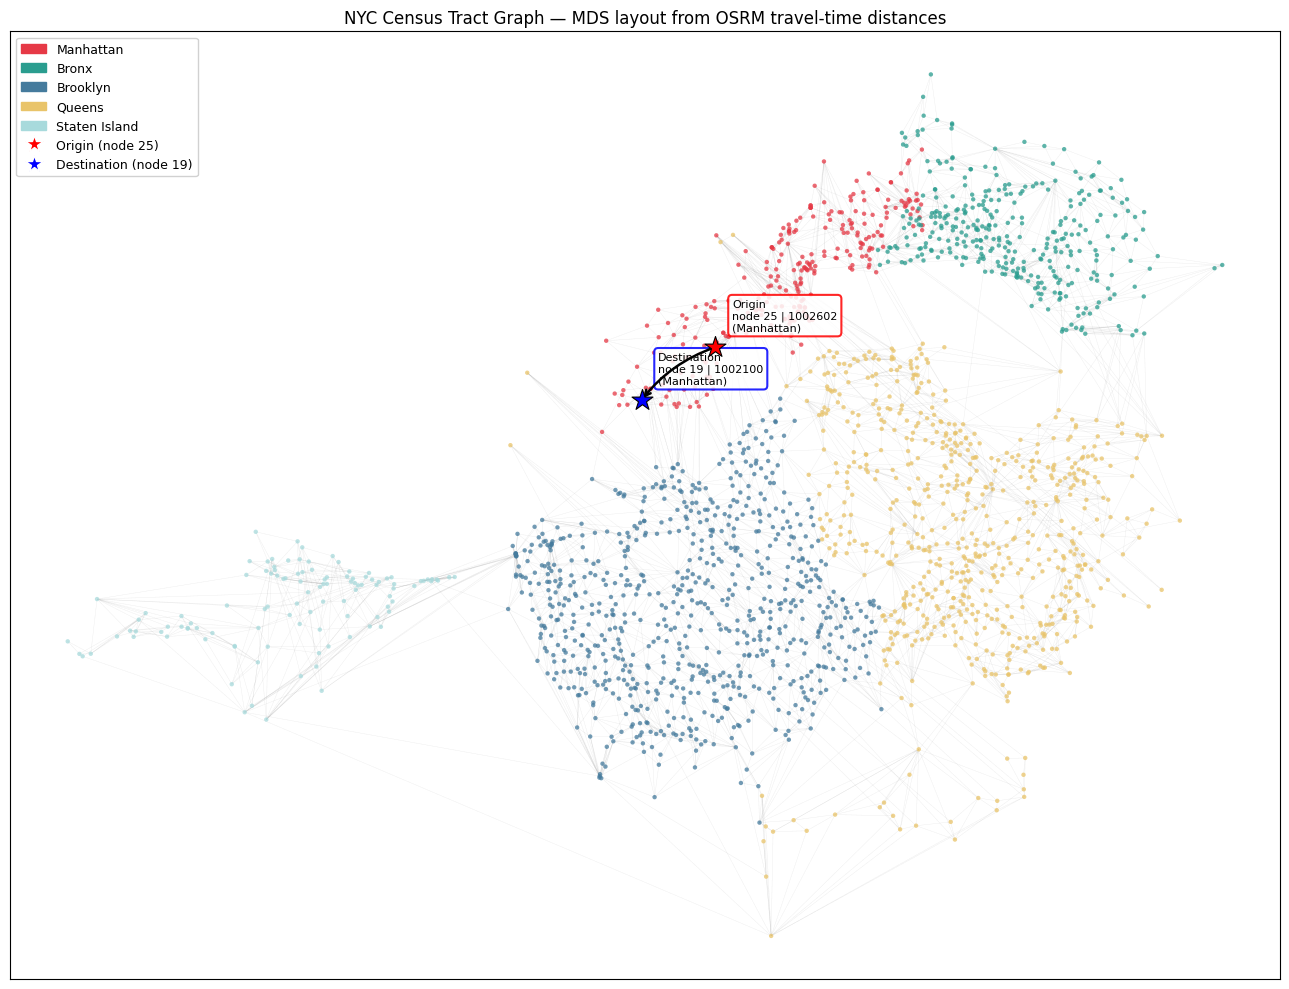

In [4]:
BOROUGH_COLORS = {
    "Manhattan":    "#e63946",
    "Bronx":        "#2a9d8f",
    "Brooklyn":     "#457b9d",
    "Queens":       "#e9c46a",
    "Staten Island":"#a8dadc",
}

node_colors = [BOROUGH_COLORS[node2boro[i]] for i in range(num_nodes)]

# Build highlighted node info
highlights = {
    SRC_NODE: ("red",  f"Origin\nnode {SRC_NODE} | {node2ct[SRC_NODE]}\n({node2boro[SRC_NODE]})"),
    DST_NODE: ("blue", f"Destination\nnode {DST_NODE} | {node2ct[DST_NODE]}\n({node2boro[DST_NODE]})"),
}
if MODIFIED_NODE not in (SRC_NODE, DST_NODE):
    highlights[MODIFIED_NODE] = (
        "limegreen",
        f"Modified\nnode {MODIFIED_NODE} | {node2ct[MODIFIED_NODE]}\n({node2boro[MODIFIED_NODE]})"
    )

fig, ax = plt.subplots(figsize=(13, 10))

# Edges — use LineCollection for performance
segments = np.stack([pos[edge_src], pos[edge_dst]], axis=1)
lc = LineCollection(segments, colors="gray", linewidths=0.3, alpha=0.07, zorder=1)
ax.add_collection(lc)

# All nodes
ax.scatter(pos[:, 0], pos[:, 1], c=node_colors, s=10, alpha=0.75, zorder=2, linewidths=0)

# Highlighted nodes + labels
for nid, (color, label) in highlights.items():
    ax.scatter(pos[nid, 0], pos[nid, 1], c=color, s=250, marker="*",
               zorder=5, edgecolors="black", linewidths=0.8)
    ax.annotate(
        label, xy=pos[nid], xytext=(12, 12), textcoords="offset points",
        fontsize=8, color="black",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor=color, linewidth=1.5)
    )

# Arrow SRC → DST
ax.annotate(
    "", xy=pos[DST_NODE], xytext=pos[SRC_NODE],
    arrowprops=dict(arrowstyle="->", color="black", lw=1.8, connectionstyle="arc3,rad=0.15")
)

# Legend
boro_patches = [mpatches.Patch(color=c, label=b) for b, c in BOROUGH_COLORS.items()]
special = [
    Line2D([0],[0], marker="*", color="w", markerfacecolor="red",  markersize=13, label=f"Origin (node {SRC_NODE})"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="blue", markersize=13, label=f"Destination (node {DST_NODE})"),
]
if MODIFIED_NODE not in (SRC_NODE, DST_NODE):
    special.append(
        Line2D([0],[0], marker="*", color="w", markerfacecolor="limegreen", markersize=13, label=f"Modified (node {MODIFIED_NODE})")
    )
ax.legend(handles=boro_patches + special, loc="upper left", fontsize=9, framealpha=0.9)

ax.set_title("NYC Census Tract Graph — MDS layout from OSRM travel-time distances", fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.autoscale()
plt.tight_layout()
plt.show()

## 5. Local Neighborhood — Zoomed View

Shows only the K-hop graph neighborhood around the highlighted nodes.  
Adjust `K_HOPS` to see a wider or narrower neighborhood.

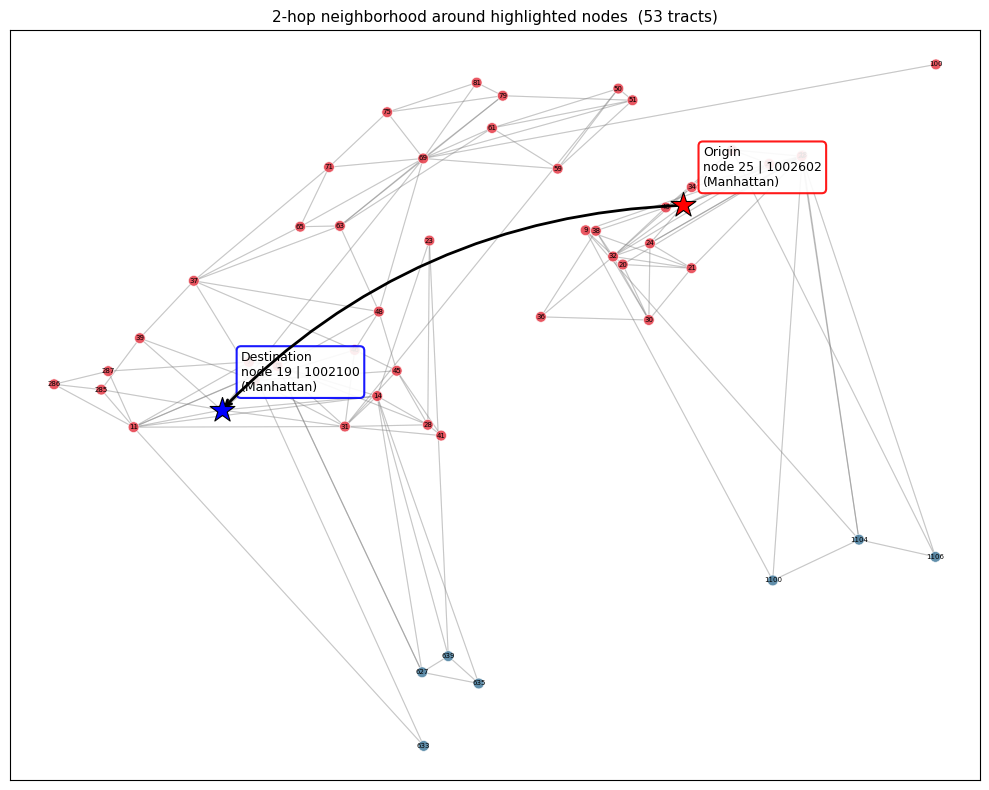

In [5]:
K_HOPS = 2

def k_hop_neighbors(seed_nodes, adj, k):
    visited  = set(seed_nodes)
    frontier = set(seed_nodes)
    for _ in range(k):
        nxt = set()
        for n in frontier:
            nxt |= set(adj[n].nonzero()[0])
        nxt -= visited
        visited |= nxt
        frontier = nxt
    return sorted(visited)

seeds       = list(highlights.keys())
sub_nodes   = k_hop_neighbors(seeds, adj_matrix, K_HOPS)
sub_set     = set(sub_nodes)

sub_mask    = np.isin(edge_src, sub_nodes) & np.isin(edge_dst, sub_nodes)
sub_src     = edge_src[sub_mask]
sub_dst     = edge_dst[sub_mask]

fig, ax = plt.subplots(figsize=(10, 8))

# Edges
segs = np.stack([pos[sub_src], pos[sub_dst]], axis=1)
ax.add_collection(LineCollection(segs, colors="gray", linewidths=0.8, alpha=0.25, zorder=1))

# Background nodes in subgraph
sub_colors = [node_colors[n] for n in sub_nodes]
sub_pos    = pos[sub_nodes]
ax.scatter(sub_pos[:, 0], sub_pos[:, 1], c=sub_colors, s=60, alpha=0.85,
           zorder=2, linewidths=0.5, edgecolors="white")

# Node ID labels
for n in sub_nodes:
    ax.text(pos[n, 0], pos[n, 1], str(n), fontsize=5, ha="center", va="center",
            zorder=3, color="black")

# Highlighted nodes
for nid, (color, label) in highlights.items():
    ax.scatter(pos[nid, 0], pos[nid, 1], c=color, s=350, marker="*",
               zorder=5, edgecolors="black", linewidths=0.8)
    ax.annotate(
        label, xy=pos[nid], xytext=(14, 14), textcoords="offset points",
        fontsize=9, color="black",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9, edgecolor=color, linewidth=1.5)
    )

# Arrow SRC → DST
ax.annotate(
    "", xy=pos[DST_NODE], xytext=pos[SRC_NODE],
    arrowprops=dict(arrowstyle="->", color="black", lw=2, connectionstyle="arc3,rad=0.2")
)

ax.set_title(
    f"{K_HOPS}-hop neighborhood around highlighted nodes  ({len(sub_nodes)} tracts)",
    fontsize=11
)
ax.set_xticks([])
ax.set_yticks([])
ax.autoscale()
plt.tight_layout()
plt.show()